# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

## 🖼️ Visualize Sample Images

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

## 📈 Compare Learning Curves

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## 🎓 Student Learning Tasks - Completed

### ✅ Beginner Task 1: Increase ANN layers and observe performance, with increased epochs and EarlyStopping

In [11]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- BEGIN: Comprehensive Notebook State Setup for Student Tasks ---

# 1. Load Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# 2. Preprocessing
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 3. Original ANN Model Training
ann_model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("\nTraining Original ANN Model...")
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=0 # Suppress verbose output for cleaner log
)
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print("Original ANN Test Accuracy:", ann_test_acc)

# 4. Original CNN Model Training
cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("\nTraining Original CNN Model...")
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=0 # Suppress verbose output for cleaner log
)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print("Original CNN Test Accuracy:", cnn_test_acc)

# Define EarlyStopping callback (used by all new models)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# --- END: Comprehensive Notebook State Setup ---


# --- BEGIN: Student Task 1: ANN Model V2 ---
print("\nTraining ANN Model V2 (more layers, 20 epochs, EarlyStopping)...")
ann_model_v2 = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=20, # Increased epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0 # Suppress verbose output for cleaner log
)

ann_test_loss_v2, ann_test_acc_v2 = ann_model_v2.evaluate(x_test_flat, y_test, verbose=0)
print("ANN V2 Test Accuracy:", ann_test_acc_v2)
# --- END: Student Task 1: ANN Model V2 ---


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Original ANN Model...
Original ANN Test Accuracy: 0.43220001459121704

Training Original CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Original CNN Test Accuracy: 0.7127000093460083

Training ANN Model V2 (more layers, 20 epochs, EarlyStopping)...
ANN V2 Test Accuracy: 0.44519999623298645


### ✅ Beginner Task 2: Change CNN filters from 32→64→128, with increased epochs and EarlyStopping

In [12]:
# --- BEGIN: Student Task 2: CNN Model V2 ---
print("\nTraining CNN Model V2 (more filters, 20 epochs, EarlyStopping)...")
cnn_model_v2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)), # Changed from 32
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'), # Changed from 64
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(256, (3,3), activation='relu'), # Changed from 128
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20, # Increased epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0 # Suppress verbose output for cleaner log
)

cnn_test_loss_v2, cnn_test_acc_v2 = cnn_model_v2.evaluate(x_test_norm, y_test, verbose=0)
print("CNN V2 Test Accuracy:", cnn_test_acc_v2)
# --- END: Student Task 2: CNN Model V2 ---



Training CNN Model V2 (more filters, 20 epochs, EarlyStopping)...
CNN V2 Test Accuracy: 0.7350999712944031


### ✅ Beginner Task 5: Add data augmentation training (with increased epochs and EarlyStopping)

In [13]:
# --- BEGIN: Student Task 5: Data Augmentation Training ---
print("\nTraining Data Augmented CNN Model (20 epochs, EarlyStopping)... ")
data_augmentation = tf.keras.models.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

aug_cnn_model = tf.keras.models.Sequential([
    data_augmentation,
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20, # Increased epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0 # Suppress verbose output for cleaner log
)

aug_cnn_test_loss, aug_cnn_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print("Data Augmented CNN Test Accuracy:", aug_cnn_test_acc)
# --- END: Student Task 5: Data Augmentation Training ---



Training Data Augmented CNN Model (20 epochs, EarlyStopping)... 
Data Augmented CNN Test Accuracy: 0.447299987077713


### 📈 Compare Learning Curves (Updated)

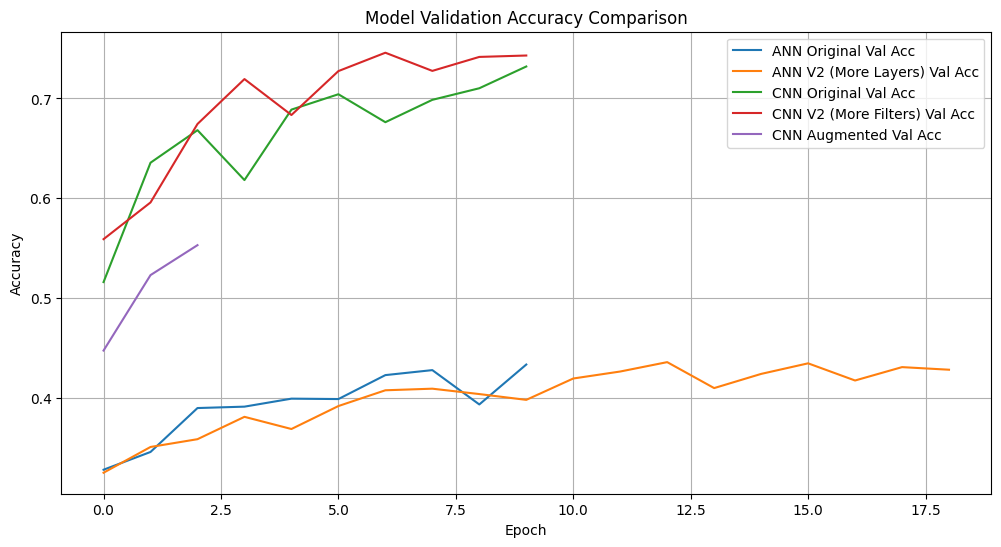

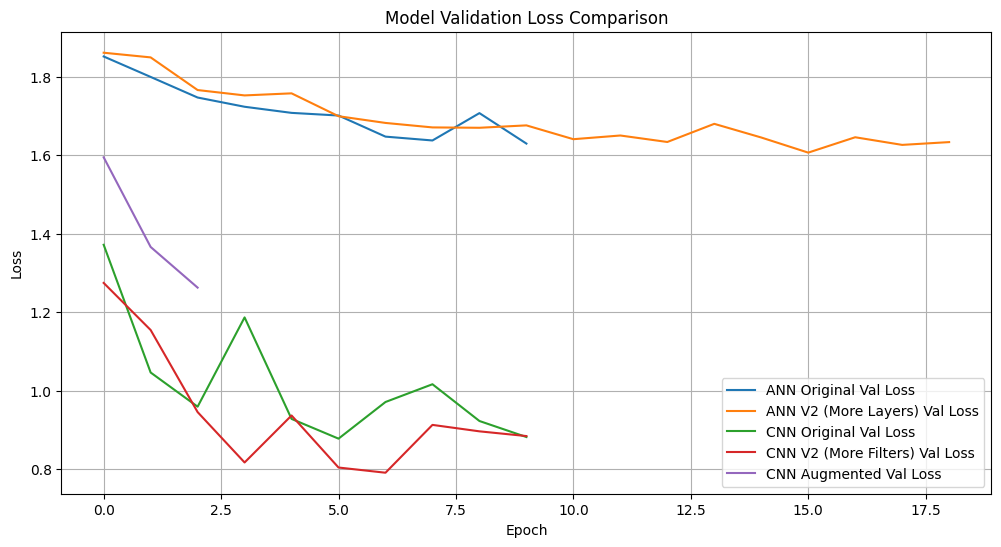

In [14]:
# --- BEGIN: Compare Learning Curves (Updated) ---
plt.figure(figsize=(12, 6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(ann_history_v2.history['val_accuracy'], label='ANN V2 (More Layers) Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(cnn_history_v2.history['val_accuracy'], label='CNN V2 (More Filters) Val Acc')
plt.plot(aug_history.history['val_accuracy'], label='CNN Augmented Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Validation Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(ann_history.history['val_loss'], label='ANN Original Val Loss')
plt.plot(ann_history_v2.history['val_loss'], label='ANN V2 (More Layers) Val Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Original Val Loss')
plt.plot(cnn_history_v2.history['val_loss'], label='CNN V2 (More Filters) Val Loss')
plt.plot(aug_history.history['val_loss'], label='CNN Augmented Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()
# --- END: Compare Learning Curves (Updated) ---


### 📊 Final Comparison Table (Updated)

In [15]:
# --- BEGIN: Final Comparison Table (Updated) ---
comparison_final = pd.DataFrame({
    "Model": [
        "ANN Original", "ANN V2 (More Layers)",
        "CNN Original", "CNN V2 (More Filters)",
        "CNN Augmented"
    ],
    "Test Accuracy": [
        ann_test_acc, ann_test_acc_v2,
        cnn_test_acc, cnn_test_acc_v2,
        aug_cnn_test_acc
    ]
})
comparison_final.sort_values(by="Test Accuracy", ascending=False)
# --- END: Final Comparison Table (Updated) ---


,Model,Test Accuracy
3,CNN V2 (More Filters),0.7351
2,CNN Original,0.7127
4,CNN Augmented,0.4473
1,ANN V2 (More Layers),0.4452
0,ANN Original,0.4322


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## Resources